# 06 - Tipo de defeito (Tarefa 2)

Identifica **qual o tipo de defeito** (ex.: `broken_large`, `contamination`)
usando features ResNet18 + LogisticRegression, um classificador por categoria.

> Como o MVTec não tem defeitos no treino, os defeitos do `test/` foram
> divididos (estratificado) em treino/teste — baseline ilustrativo.
> Lê os artefactos de `scripts/train_eval_defect_classifier.py`.

## 0. Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
RESULTS = ROOT / "results"
MODELS = ROOT / "models"
sys.path.append(str(SRC))


import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def carregar_json(c):
    with open(c, encoding="utf-8") as f:
        return json.load(f)


def existe(c):
    c = Path(c)
    if not c.exists():
        print(f"[FALTA] {c.name} — corre o script correspondente primeiro.")
        return False
    return True


def desnormalizar(t):
    img = t.detach().cpu().numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)


def mostrar_matriz_confusao(matriz, etiquetas, titulo, ax=None):
    matriz = np.asarray(matriz)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(matriz, cmap="Blues")
    ax.set_title(titulo)
    ax.set_xticks(range(len(etiquetas))); ax.set_yticks(range(len(etiquetas)))
    ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(etiquetas, fontsize=8)
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
    lim = matriz.max() / 2 if matriz.max() else 0.5
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, int(matriz[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if matriz[i, j] > lim else "black")
    return ax

print("ROOT:", ROOT, "| device:", device)

ROOT: C:\Users\maria\Desktop\projeto | device: cuda


## 1. Accuracy e macro-F1 por categoria

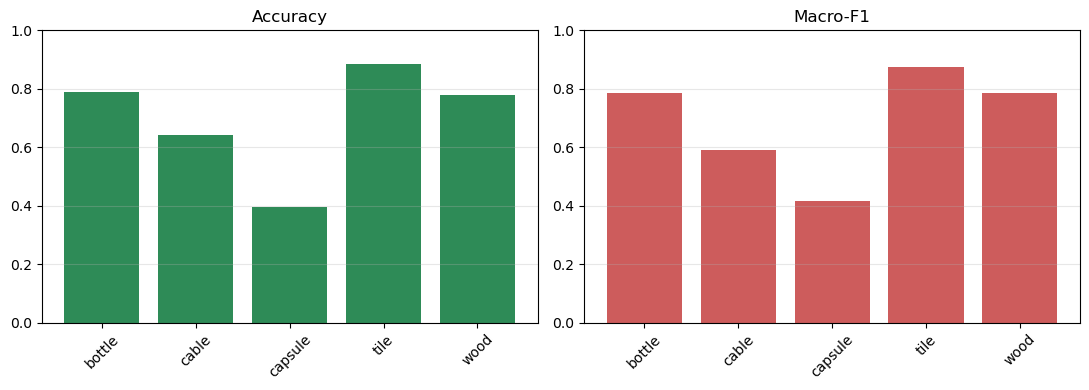

,category,n_classes,n_train,n_test,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,bottle,3,44,19,0.7895,0.7857,0.7937,0.7863,0.7854
1,cable,8,64,28,0.6429,0.6256,0.6458,0.5903,0.5934
2,capsule,5,76,33,0.3939,0.4766,0.3952,0.4161,0.4131
3,tile,5,58,26,0.8846,0.8767,0.8800,0.8752,0.8800
4,wood,5,42,18,0.7778,0.8500,0.8000,0.7848,0.7873


In [2]:
import pandas as pd
caminho = RESULTS / "defect_classifier_summary.csv"
if existe(caminho):
    df = pd.read_csv(caminho)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(df["category"], df["accuracy"], color="seagreen"); axes[0].set_title("Accuracy"); axes[0].set_ylim(0, 1)
    axes[1].bar(df["category"], df["macro_f1"], color="indianred"); axes[1].set_title("Macro-F1"); axes[1].set_ylim(0, 1)
    for ax in axes:
        ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()
    display(df.round(4))

## 2. Matrizes de confusão por categoria

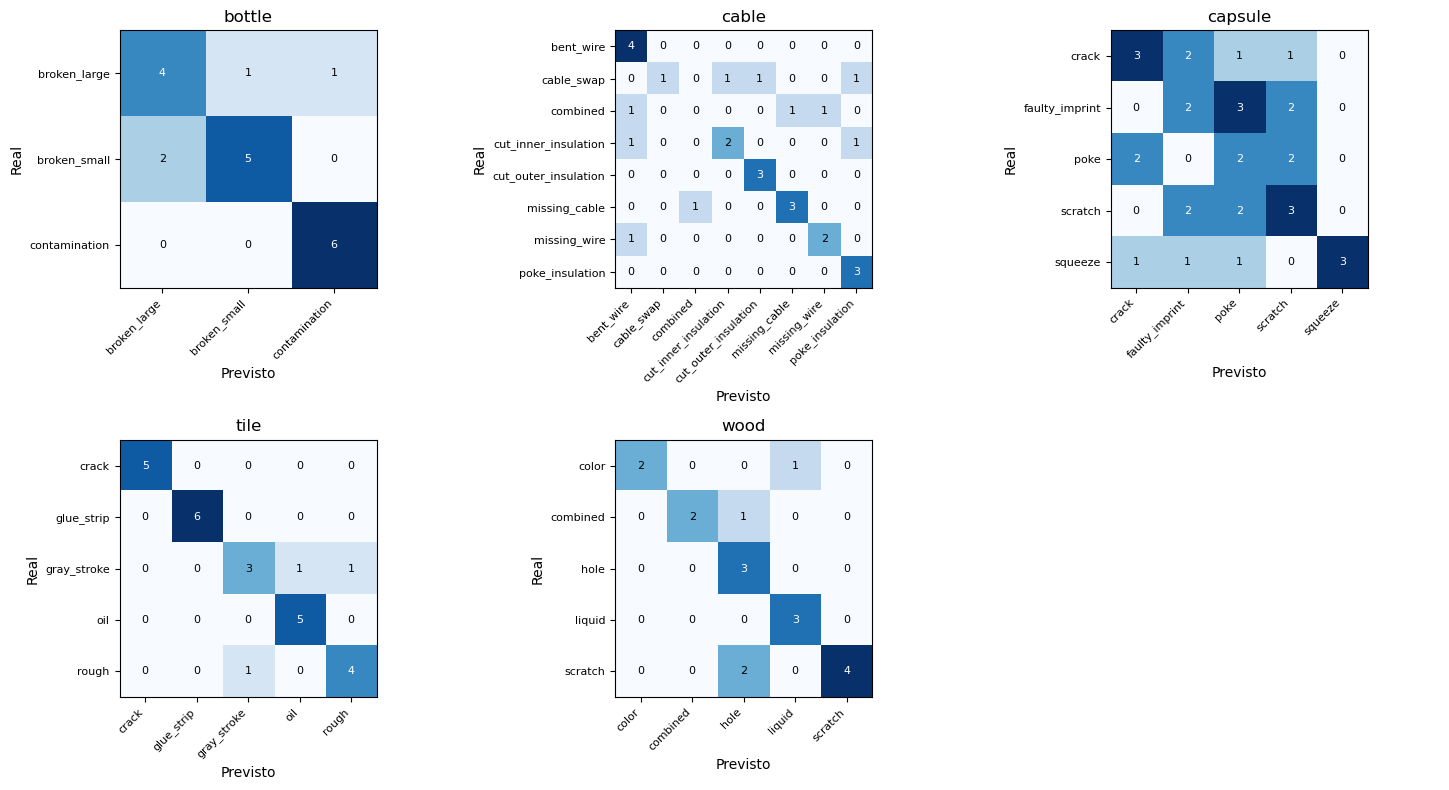

In [3]:
CATEGORIAS = ["bottle", "cable", "capsule", "tile", "wood"]
disponiveis = [c for c in CATEGORIAS if (RESULTS / f"defect_classifier_{c}_metrics.json").exists()]
if disponiveis:
    cols = 3; linhas = (len(disponiveis) + cols - 1) // cols
    fig, axes = plt.subplots(linhas, cols, figsize=(5 * cols, 4 * linhas))
    axes = np.array(axes).reshape(-1)
    for ax, cat in zip(axes, disponiveis):
        m = carregar_json(RESULTS / f"defect_classifier_{cat}_metrics.json")["metrics"]
        mostrar_matriz_confusao(m["confusion_matrix"], m["labels"], cat, ax=ax)
    for ax in axes[len(disponiveis):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

## 3. Exemplos classificados (verde = acertou, vermelho = errou)

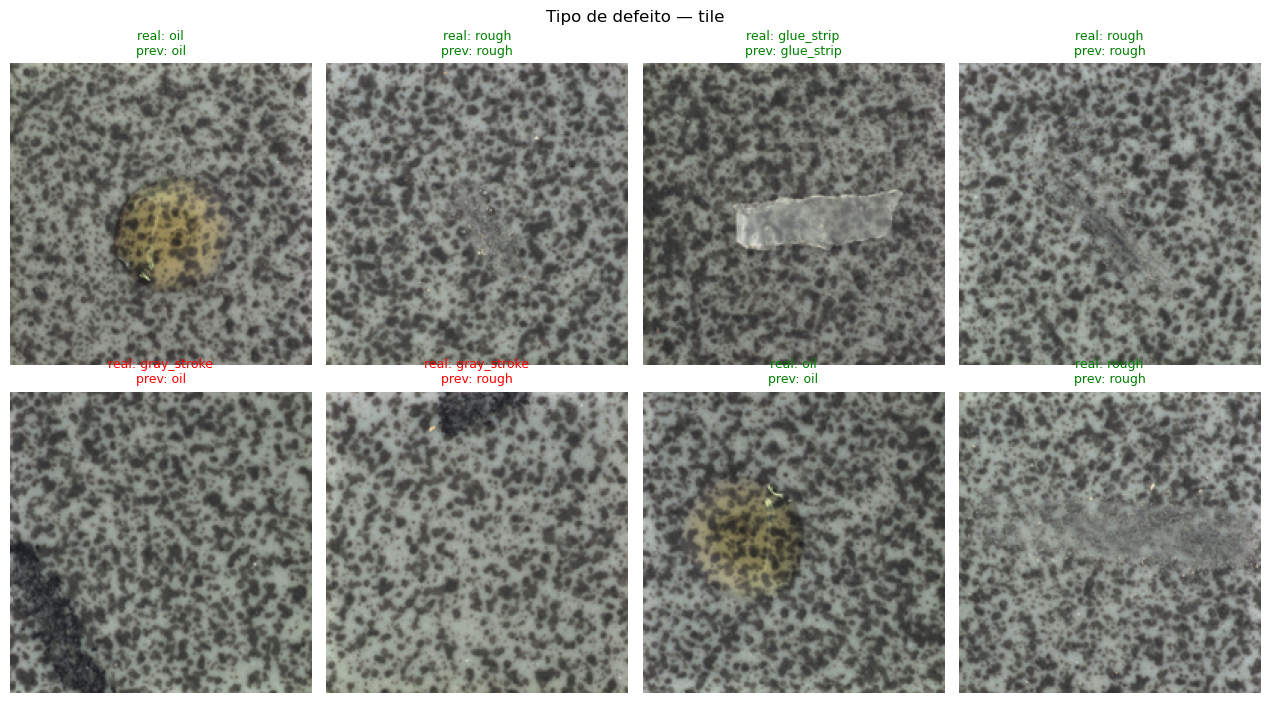

In [4]:
import joblib
from category_protocol import category_defective_records
from eval_resnet import build_resnet18_feature_extractor, extract_features
from PIL import Image

CATEGORIA_EXEMPLO = "tile"   # muda para ver outra categoria
SEED_AMOSTRA = 7
caminho_clf = MODELS / f"defect_classifier_{CATEGORIA_EXEMPLO}.joblib"
if existe(caminho_clf):
    clf = joblib.load(caminho_clf)["classifier"]
    resnet, preprocess = build_resnet18_feature_extractor(device)
    registos = category_defective_records(CATEGORIA_EXEMPLO)
    rng = np.random.default_rng(SEED_AMOSTRA)
    n = min(8, len(registos))
    escolhidos = list(rng.choice(np.array(registos, dtype=object), size=n, replace=False))
    feats = extract_features([r.path for r in escolhidos], resnet, preprocess, device)
    previstos = clf.predict(feats)
    cols = 4; linhas = (n + cols - 1) // cols
    fig, axes = plt.subplots(linhas, cols, figsize=(3.2 * cols, 3.6 * linhas))
    axes = np.array(axes).reshape(-1)
    for ax, r, prev in zip(axes, escolhidos, previstos):
        ax.imshow(Image.open(r.path).convert("RGB").resize((200, 200)))
        cor = "green" if prev == r.defect_type else "red"
        ax.set_title(f"real: {r.defect_type}\nprev: {prev}", color=cor, fontsize=9); ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.suptitle(f"Tipo de defeito — {CATEGORIA_EXEMPLO}"); plt.tight_layout(); plt.show()